In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Downloading required NLTK resources

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jeete\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jeete\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jeete\AppData\Roaming\nltk_data...


True

In [3]:
# Loading dataset

df = pd.read_csv("IMDB Dataset.csv")

In [4]:
# Displaying first 5 records
df.head()
# Checking dataset dimensions
print("Dataset Shape:", df.shape)
# Checking dataset information
df.info()
# Checking missing values
df.isnull().sum()
# Checking duplicate records
df.duplicated().sum()

Dataset Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


np.int64(418)

In [5]:
# Removing duplicate reviews

df = df.drop_duplicates()

# Verifying duplicate removal

print("Duplicate Records:", df.duplicated().sum())

# Checking updated shape

print("Updated Dataset Shape:", df.shape)

Duplicate Records: 0
Updated Dataset Shape: (49582, 2)


sentiment
positive    24884
negative    24698
Name: count, dtype: int64


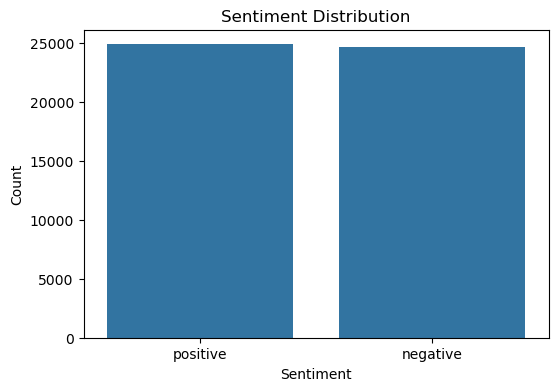

In [6]:
# Checking sentiment distribution
print(df['sentiment'].value_counts())

# Visualizing sentiment distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment',
    data=df
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [7]:
# Creating lemmatizer and stopword list

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

In [8]:
# Defining text preprocessing function

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = text.split()

    # Stopword removal and lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into text
    return " ".join(words)

In [9]:
# Applying preprocessing to reviews

df['clean_review'] = df['review'].apply(clean_text)

In [10]:
# Comparing original and cleaned reviews

df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [11]:
# Checking updated dataset

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [12]:
# Encoding sentiment labels

df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stunnin...


In [13]:
# Converting text into TF-IDF features

vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(
    df['clean_review']
)

y = df['sentiment']

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (49582, 5000)


In [14]:
# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (39665, 5000)
Testing Data Shape: (9917, 5000)


In [15]:
# Importing Naive Bayes classifier

from sklearn.naive_bayes import MultinomialNB

# Creating and training model

nb_model = MultinomialNB()

nb_model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [16]:
# Predicting sentiments

y_pred = nb_model.predict(X_test)

# Evaluating model performance

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score:
0.8520721992538066

Confusion Matrix:
[[4166  773]
 [ 694 4284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4939
           1       0.85      0.86      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



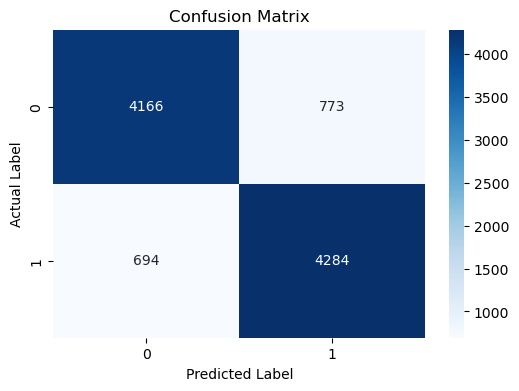

In [17]:
# Visualizing confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [18]:
# Saving processed dataset

df.to_csv(
    "IMDB_Cleaned_Dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.
